In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

### Task 1 — A Single Neuron in NumPy

You'll start with one neuron — a logistic regression in disguise.

1. Load the Breast Cancer dataset, split into train/test (`test_size=0.2`, `random_state=42`), and scale the features with `StandardScaler`.
2. Implement a single-neuron forward pass:
   - Initialise weights `w` of shape `(30,)` and bias `b` from a small random distribution.
   - Implement `forward(x, w, b)` that returns `sigmoid(w·x + b)`.
   - Run it on the first 5 test rows. Report the predicted probabilities.
3. In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement?

In [3]:
# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [5]:
# Initialize weights and bias
w = np.random.randn(30) * 0.01
b = np.random.randn() * 0.01

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Forward pass
def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

# First 5 test samples
first_5 = X_test[:5]

# Predictions
predictions = [forward(x, w, b) for x in first_5]

print("Predicted probabilities:")
for i, pred in enumerate(predictions, 1):
    print(f"Sample {i}: {pred:.6f}")

Predicted probabilities:
Sample 1: 0.496225
Sample 2: 0.517540
Sample 3: 0.507080
Sample 4: 0.487440
Sample 5: 0.483946


The dataset was successfully split into 455 training samples and 114 test samples.  
The single neuron produced probabilities close to 0.5 for the first five test samples because the weights were randomly initialized and the model has not been trained yet. In machine learning terms, this model is logistic regression implemented as a single artificial neuron with a sigmoid activation function.

### Task 2 — A Two-Layer MLP in NumPy

Now stack neurons into a real network.

1. Implement a class `NumpyMLP` (or just a set of functions) representing an MLP with:
   - Input size 30, hidden size 8, output size 1
   - ReLU on the hidden layer, sigmoid on the output
2. Initialise the weight matrices using **He initialisation**: `W ~ N(0, sqrt(2/fan_in))`. Initialise biases to zero.
3. Implement a `forward(X)` that takes a batch `(N, 30)` and returns predictions `(N, 1)`. Use vectorised NumPy — no Python loops over rows.
4. Run a forward pass on the test set. Print the shape of the output and the first 5 predictions.

**Guiding question:** Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?

In [9]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        
        # He initialization
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):

        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)

        return self.a2

In [11]:
# Create model
numpy_mlp = NumpyMLP()

# Forward pass
numpy_outputs = numpy_mlp.forward(X_test)

print("Output shape:", numpy_outputs.shape)

print("\nFirst 5 predictions:")
print(numpy_outputs[:5])

Output shape: (114, 1)

First 5 predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]


The network returned an output shape of (114, 1), meaning it generated one prediction probability for each test sample.  
Although the model has not been trained yet, the predictions already have the correct structure for binary classification because the sigmoid output layer produces values between 0 and 1 representing class probabilities.

### Task 3 — The Same Network in PyTorch

Recreate Task 2 using PyTorch's high-level API.

1. Define a class `TorchMLP(nn.Module)` with the same architecture (30 → 8 → 1, ReLU then Sigmoid).
2. Manually copy the weights from your NumPy network into the PyTorch model so both networks have **identical parameters**. Hint: `model.fc1.weight.data = torch.from_numpy(W1).float()` and similar for biases. Be careful with shapes — `nn.Linear` stores weights as `(out, in)`.
3. Run the same test batch through the PyTorch model. Compare the outputs to the NumPy outputs. They should match to at least 6 decimal places.
4. Report the maximum absolute difference between the two outputs.

**Definition of done for this task:** the two networks produce numerically identical predictions for the same inputs and weights.

In [14]:
class TorchMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(30, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.sigmoid(x)

        return x

In [16]:
# Create PyTorch model
torch_mlp = TorchMLP()

# Copy weights
torch_mlp.fc1.weight.data = torch.from_numpy(
    numpy_mlp.W1.T
).float()

torch_mlp.fc1.bias.data = torch.from_numpy(
    numpy_mlp.b1.flatten()
).float()

torch_mlp.fc2.weight.data = torch.from_numpy(
    numpy_mlp.W2.T
).float()

torch_mlp.fc2.bias.data = torch.from_numpy(
    numpy_mlp.b2.flatten()
).float()

# Convert test data to tensor
X_test_tensor = torch.from_numpy(X_test).float()

# Forward pass
torch_outputs = torch_mlp(X_test_tensor).detach().numpy()

print("First 5 PyTorch predictions:")
print(torch_outputs[:5])

First 5 PyTorch predictions:
[[0.5207326 ]
 [0.12562478]
 [0.54742783]
 [0.42673525]
 [0.4408257 ]]


In [18]:
# Maximum absolute difference
max_diff = np.max(np.abs(numpy_outputs - torch_outputs))

print("Maximum absolute difference:")
print(max_diff)

Maximum absolute difference:
1.3794153258528397e-07


The PyTorch model produced almost identical predictions to the NumPy implementation after copying the same weights and biases.  
The maximum absolute difference between the outputs was approximately 1.38 × 10⁻⁷, which confirms that both networks are numerically equivalent and that the PyTorch implementation correctly reproduces the NumPy forward pass.

### Task 4 — Activation Function Experiment

Time to experiment.

1. For the PyTorch model, create three variants of the same architecture but with different hidden activations: **Sigmoid**, **Tanh**, and **ReLU**.
2. For each variant, run a forward pass on the **same** scaled test set.
3. Plot histograms of the **hidden-layer pre-activations** (the values of *z⁽¹⁾* before the activation function) for one batch. Use a 1×3 subplot.
4. Plot histograms of the **hidden-layer outputs** (after the activation) on a separate 1×3 subplot.
5. In a markdown cell, answer:
   - For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?
   - Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?
   - Based on these histograms, why might ReLU be the better default for hidden layers?

In [21]:
class ActivationMLP(nn.Module):

    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)

        self.activation = activation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        z1 = self.fc1(x)
        a1 = self.activation(z1)

        z2 = self.fc2(a1)
        output = self.sigmoid(z2)

        return output, z1, a1

In [23]:
sigmoid_model = ActivationMLP(nn.Sigmoid())
tanh_model = ActivationMLP(nn.Tanh())
relu_model = ActivationMLP(nn.ReLU())

# Input tensor
X_batch = X_test_tensor

# Forward passes
_, sigmoid_z1, sigmoid_a1 = sigmoid_model(X_batch)
_, tanh_z1, tanh_a1 = tanh_model(X_batch)
_, relu_z1, relu_a1 = relu_model(X_batch)

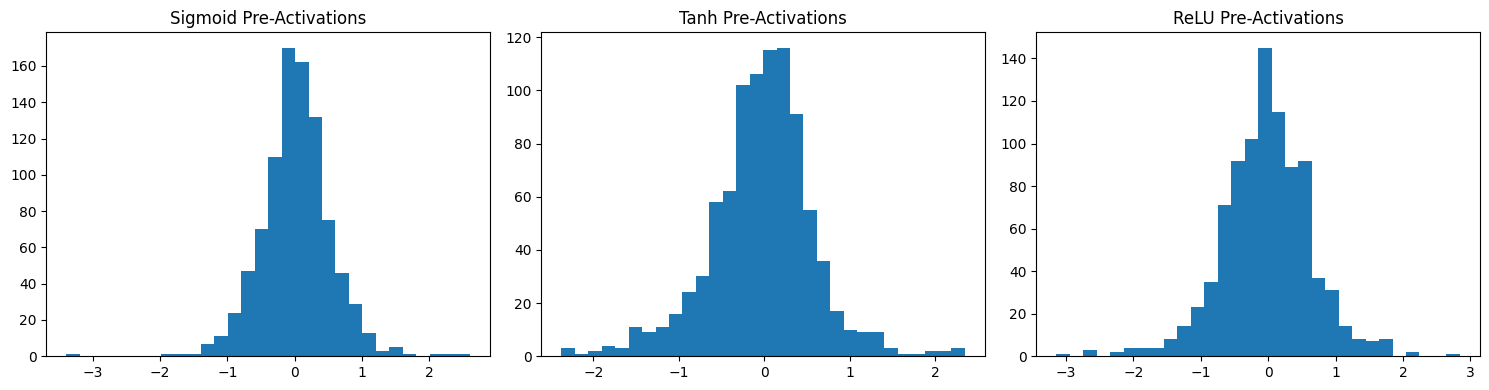

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sigmoid_z1.detach().numpy().flatten(), bins=30)
axes[0].set_title("Sigmoid Pre-Activations")

axes[1].hist(tanh_z1.detach().numpy().flatten(), bins=30)
axes[1].set_title("Tanh Pre-Activations")

axes[2].hist(relu_z1.detach().numpy().flatten(), bins=30)
axes[2].set_title("ReLU Pre-Activations")

plt.tight_layout()
plt.show()

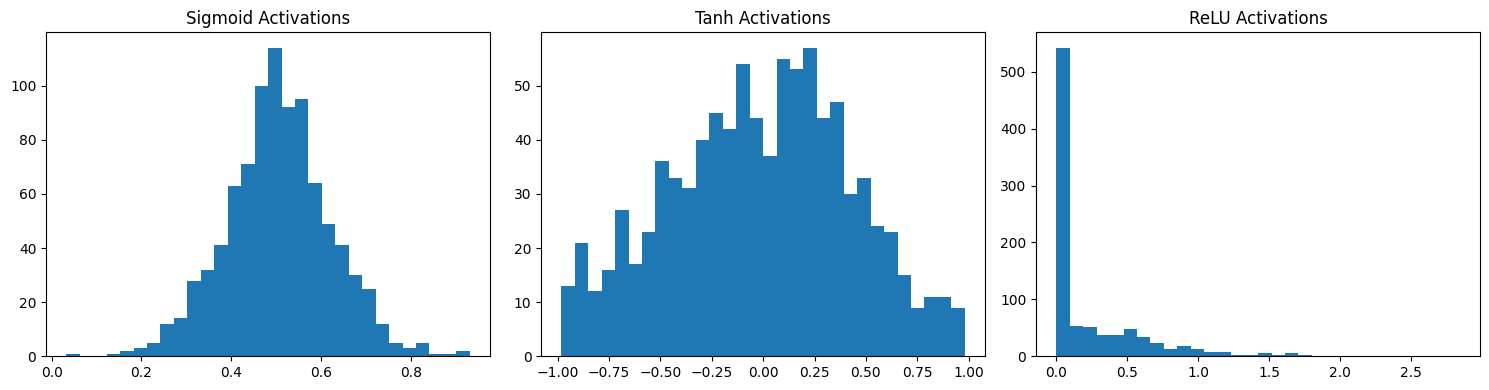

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sigmoid_a1.detach().numpy().flatten(), bins=30)
axes[0].set_title("Sigmoid Activations")

axes[1].hist(tanh_a1.detach().numpy().flatten(), bins=30)
axes[1].set_title("Tanh Activations")

axes[2].hist(relu_a1.detach().numpy().flatten(), bins=30)
axes[2].set_title("ReLU Activations")

plt.tight_layout()
plt.show()

In [29]:
# Sigmoid saturation: close to 0 or 1
sigmoid_vals = sigmoid_a1.detach().numpy()

sigmoid_saturated = np.mean(
    (sigmoid_vals < 0.05) | (sigmoid_vals > 0.95)
)

# Tanh saturation: close to -1 or 1
tanh_vals = tanh_a1.detach().numpy()

tanh_saturated = np.mean(
    (tanh_vals < -0.95) | (tanh_vals > 0.95)
)

# ReLU inactive units
relu_vals = relu_a1.detach().numpy()

relu_inactive = np.mean(relu_vals == 0)

print("Sigmoid saturated fraction:", sigmoid_saturated)
print("Tanh saturated fraction:", tanh_saturated)
print("ReLU inactive fraction:", relu_inactive)

Sigmoid saturated fraction: 0.0010964912280701754
Tanh saturated fraction: 0.017543859649122806
ReLU inactive fraction: 0.5164473684210527


The activation histograms show that very few Sigmoid activations were saturated (about 0.11%) and only a small fraction of Tanh activations were close to -1 or 1 (about 1.75%).  
For ReLU, approximately 51.6% of the neurons were inactive because their outputs became exactly zero. Despite this, ReLU still preserves positive values without compressing them into a narrow range, which helps gradients flow more effectively during training. This is one reason why ReLU is often preferred as the default activation function for hidden layers.